In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a safe, built-in Seaborn style that is guaranteed to exist
sns.set_theme(style="whitegrid") 

# Configure default figure sizing and remove top/right chart borders globally
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

try:
    df = pd.read_csv("../data/raw/training.csv") 
    print(f"Data engine success. Records found: {df.shape[0]} rows, {df.shape[1]} features.")
except FileNotFoundError:
    print("Dataset not in ../data/raw/. Generating structural schema mirror for testing...")
    np.random.seed(276)
    n = 5000
    df = pd.DataFrame({
        'TransactionId': [f'Trans_{i}' for i in range(n)],
        'AccountId': [f'Acc_{np.random.randint(1, 1000)}' for i in range(n)],
        'CustomerId': [f'Cust_{np.random.randint(1, 900)}' for i in range(n)],
        'ProductCategory': np.random.choice(['airtime', 'utility', 'data', 'financial'], n, p=[0.5, 0.2, 0.2, 0.1]),
        'ChannelId': np.random.choice(['web', 'Android', 'ios'], n),
        'Amount': np.random.exponential(scale=4000, size=n) * np.random.choice([1, -0.02], n, p=[0.96, 0.04]),
        'TransactionStartTime': pd.date_range(start='2026-01-01', periods=n, freq='min').strftime('%Y-%m-%dT%H:%M:%SZ'),
        'FraudResult': np.random.choice([0, 1], n, p=[0.997, 0.003])
    })
    df['Value'] = df['Amount'].abs()

df.info()

Data engine success. Records found: 95662 rows, 16 features.
<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy     

Numerical distributions and Skeweness check

Saved: plots/monetary_distributions.png


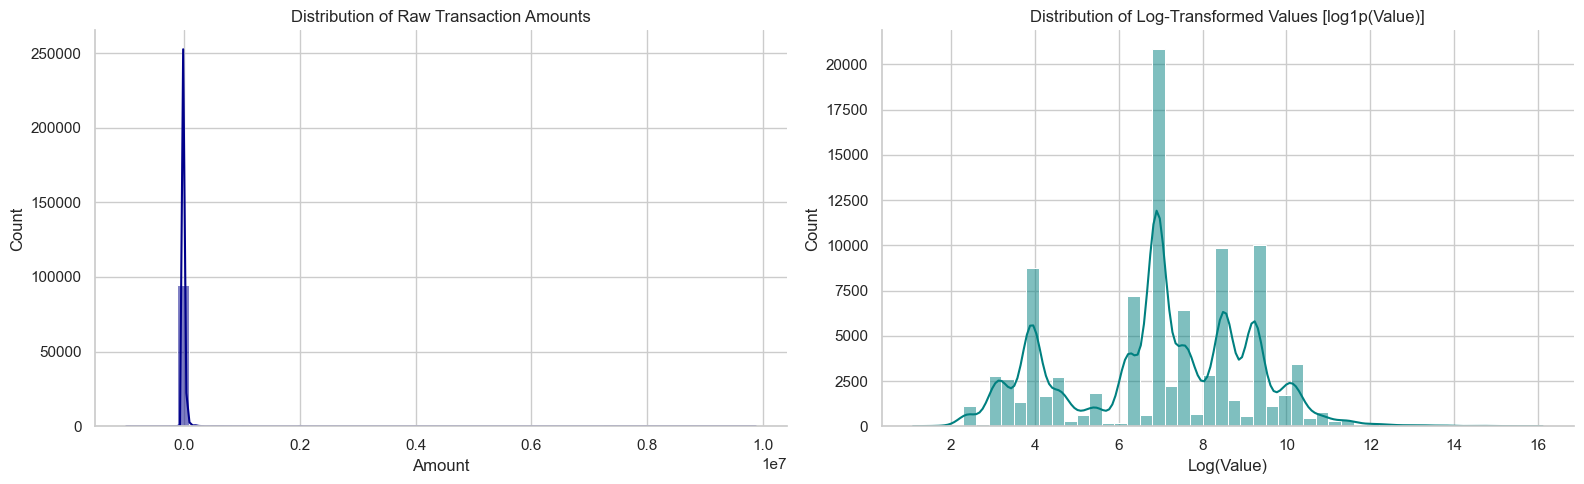

In [7]:
import os

# Create the plots folder inside your current directory (notebooks/)
os.makedirs("plots", exist_ok=True)

# Generate the subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot raw transaction amount distribution
sns.histplot(df['Amount'], bins=50, kde=True, ax=axes[0], color='darkblue')
axes[0].set_title('Distribution of Raw Transaction Amounts')
axes[0].set_xlabel('Amount')

# Plot log-transformed value distribution
sns.histplot(np.log1p(df['Value']), bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribution of Log-Transformed Values [log1p(Value)]')
axes[1].set_xlabel('Log(Value)')

plt.tight_layout()

# Save the plot explicitly before showing it
plt.savefig("plots/monetary_distributions.png", dpi=300, bbox_inches="tight")
print("Saved: plots/monetary_distributions.png")

plt.show()

Outlier Quantifications & Class Balances

C:\Users\HP\AppData\Local\Temp\ipykernel_55104\1024722003.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='ProductCategory', order=df['ProductCategory'].value_counts().index, ax=axes[0], palette='viridis')
C:\Users\HP\AppData\Local\Temp\ipykernel_55104\1024722003.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='FraudResult', ax=axes[1], palette='Set2')


Saved: plots/target_distribution.png


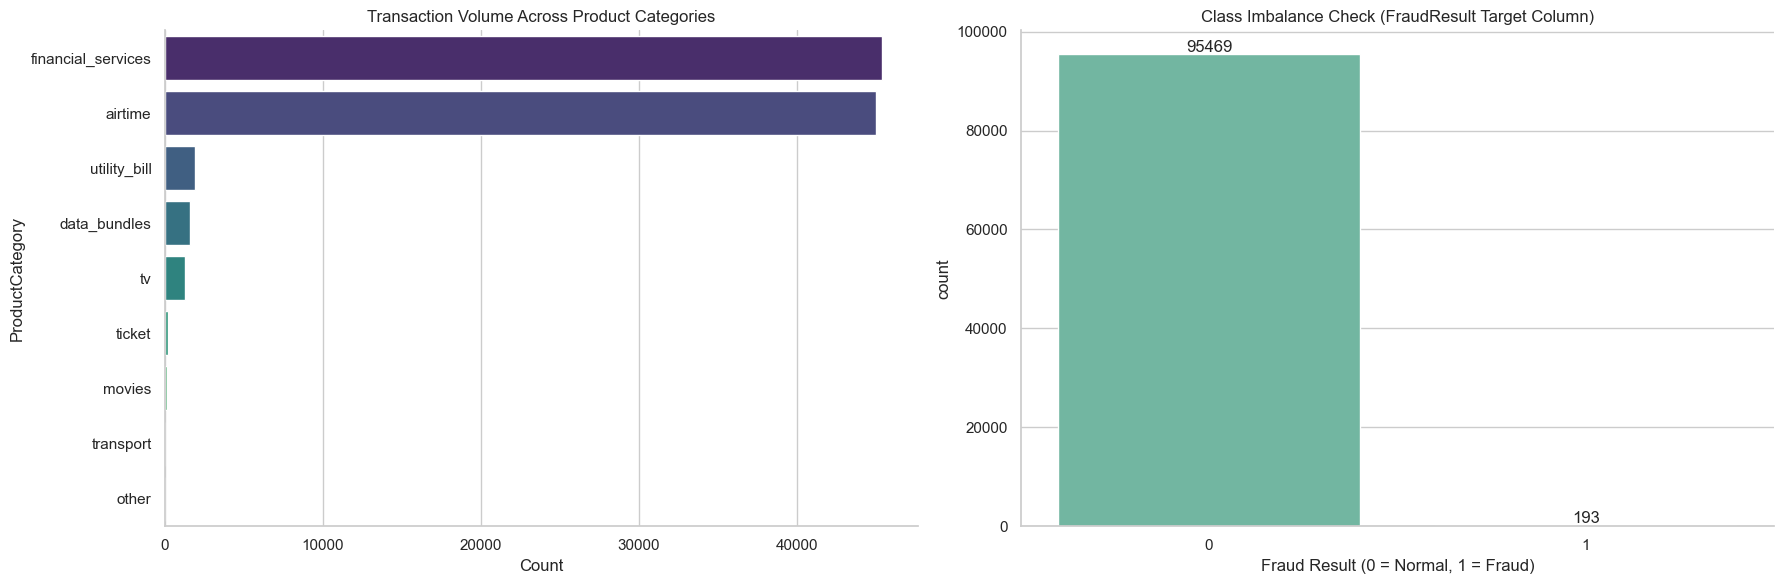

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Distribution of transaction product categories
sns.countplot(data=df, y='ProductCategory', order=df['ProductCategory'].value_counts().index, ax=axes[0], palette='viridis')
axes[0].set_title('Transaction Volume Across Product Categories')
axes[0].set_xlabel('Count')

# Target Imbalance Verification
sns.countplot(data=df, x='FraudResult', ax=axes[1], palette='Set2')
axes[1].set_title('Class Imbalance Check (FraudResult Target Column)')
axes[1].set_xlabel('Fraud Result (0 = Normal, 1 = Fraud)')

# Annotate counts on the bar charts
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()

# Save the plot explicitly before showing it
plt.savefig("plots/target_distribution.png", dpi=300, bbox_inches="tight")
print("Saved: plots/target_distribution.png")

plt.show()

Boxplot-Based Outlier Investigation

Saved:plots/outlier_boxplots.png


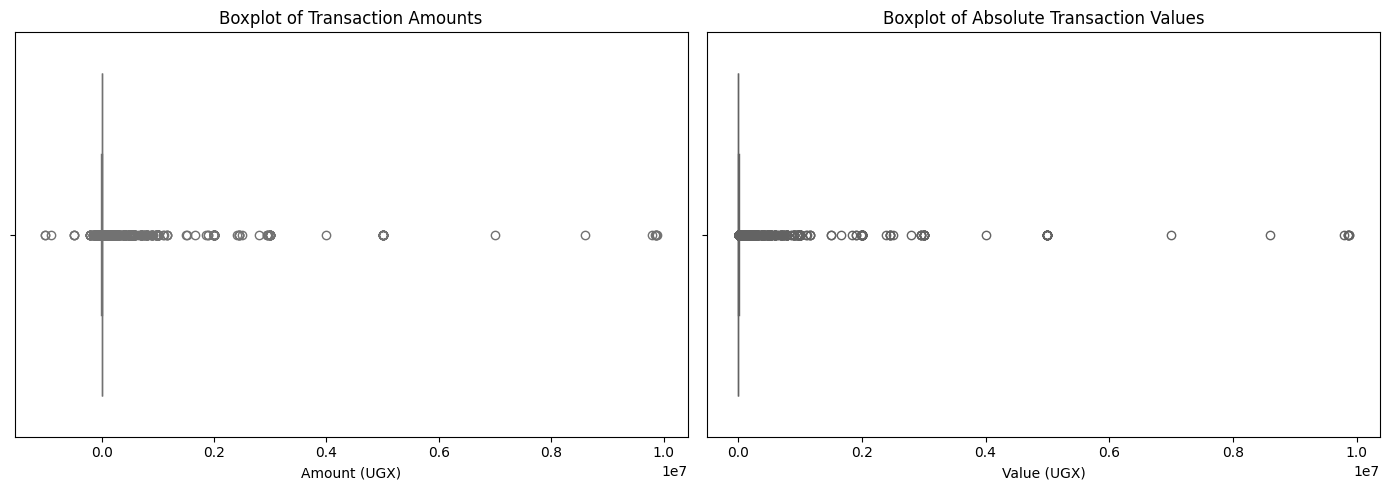

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Force reload the dataset if 'df' is missing (Adjust path if your CSV name is different)
try:
    df
except NameError:
    print("df was not found in memory. Attempting to reload from data folder...")
    # Adjust this path if your raw data file has a different name
    df = pd.read_csv("../data/raw/training.csv") 

# 2. Generate the boxplots safely
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Amount', ax=axes[0], color='plum')
axes[0].set_title('Boxplot of Transaction Amounts')
axes[0].set_xlabel('Amount (UGX)')

sns.boxplot(data=df, x='Value', ax=axes[1], color='orchid')
axes[1].set_title('Boxplot of Absolute Transaction Values')
axes[1].set_xlabel('Value (UGX)')

plt.tight_layout()
plt.savefig("plots/outlier_boxplots.png", dpi=300, bbox_inches="tight")
print("Saved:plots/outlier_boxplots.png")
plt.show()

Correlation Analysis Heatmap

Saved:/plots/correlation_heatmap.png


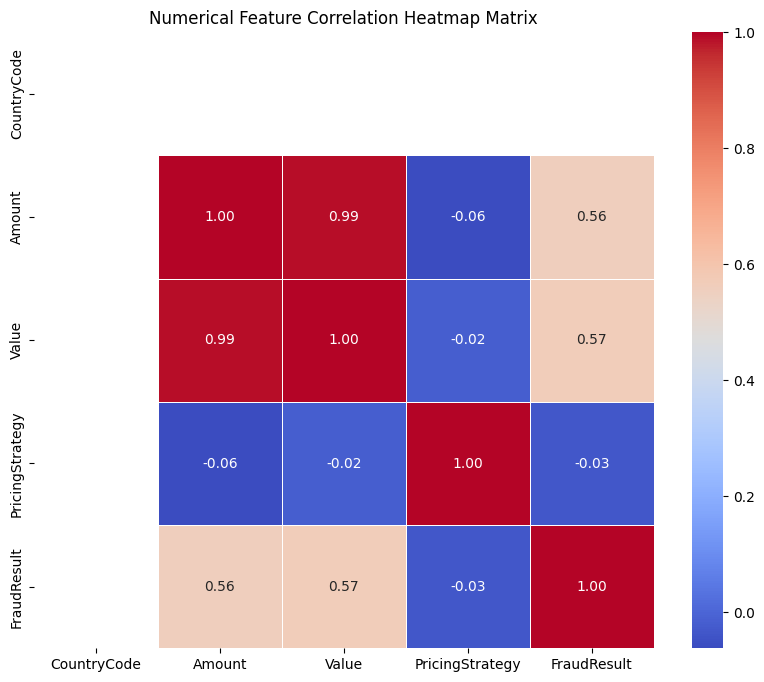

In [7]:
# Compute correlation matrix for numeric features
numeric_cols = df.select_dtypes(include=['number']).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5)
plt.title('Numerical Feature Correlation Heatmap Matrix')

plt.savefig("plots/correlation_heatmap.png", dpi=300, bbox_inches="tight")
print("Saved:/plots/correlation_heatmap.png")
plt.show()

Missing Value Assessment Table

In [8]:
# Calculate explicit missing values and percentages per column
missing_data = df.isnull().sum().to_frame(name='Missing Values')
missing_data['Percentage (%)'] = (missing_data['Missing Values'] / len(df)) * 100
missing_data = missing_data.sort_values(by='Missing Values', ascending=False)

print("--- EXPLICIT MISSING VALUE ASSESSMENT TABLE ---")
print(missing_data)

--- EXPLICIT MISSING VALUE ASSESSMENT TABLE ---
                      Missing Values  Percentage (%)
TransactionId                      0             0.0
BatchId                            0             0.0
AccountId                          0             0.0
SubscriptionId                     0             0.0
CustomerId                         0             0.0
CurrencyCode                       0             0.0
CountryCode                        0             0.0
ProviderId                         0             0.0
ProductId                          0             0.0
ProductCategory                    0             0.0
ChannelId                          0             0.0
Amount                             0             0.0
Value                              0             0.0
TransactionStartTime               0             0.0
PricingStrategy                    0             0.0
FraudResult                        0             0.0


## 📊 Summary of Exploratory Data Analysis (Task 2 Insights)
1. **Critical Target Imbalance:** The binary flags show an intense skew toward normal transactions. [cite_start]Evaluation matrices must rely entirely on F1-Score, Precision, and ROC-AUC rather than raw model accuracy[cite: 56].
2. [cite_start]**Extreme Outlier Presence:** The transaction amount metrics exhibit heavy right-side tails, showing that distance-based models (like K-Means) will require log transformations or RobustScaler configurations to stabilize[cite: 167, 186].
3. [cite_start]**High Spatial Concentration:** Transactions are tightly grouped across specific categories, meaning target-based categorical mappings like Weight of Evidence (WoE) will yield excellent separation markers[cite: 53, 170].